# Chegofatjo Mawela 

# Part A: Complexity Ladder

Under part A I invesitage the task level at which MLPs begin to degrade as compared to CNNs which maintain their performance. The structure is as follows:
- [A4.1 - Implementation](#s1)
- [A4.2 - Results Table](#s2)
- [A4.3 - Training & Validation Curves](#s3)
- [A4.4 - Analysis](#s4)
- [A4.5 - Reflection](#s5)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
#======================= Imports ========================
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from enum import Enum
from math import floor, ceil
import torch.nn as nn
import torch.nn.functional as F
import random
import os
import time




In [3]:
#deterimine device and set seeds
def set_seed(seed=42):
    # 1. Set basic Python seeds
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. Set PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # If using multi-GPU

    # 3. Force deterministic GPU operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Optional: Force PyTorch to use deterministic algorithms (will throw an error if an operation doesn't have a deterministic implementation)
    # torch.use_deterministic_algorithms(True)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
device

device(type='cuda')

<a id = 's1'></a>
## A4.1 - Implementation

In [5]:
#=============================== Dataset loading ===============================#

class DatasetType(Enum):
    """ Enum used to determine which dataset is loaded in the load_data function"""
    MNIST = "MNIST"
    CIFAR10 = "CIFAR-10"

def load_data(dataset_type: DatasetType,
              resize_mlp: bool = False,
              root: str = "/kaggle/working/data"):
    """
    Returns a tensor of either Greyscale (MNIST) or RGB (CIFAR-10) data

    Args:
        col_type: The type of data set required, defined inthe ColorType enum
        resize_mlp: A boolean indicating wether the MNIST data set is resized to (32,32)
        root: The directory which the dataset is downloaded to

    Returns:
        A dictionary containing Dataset object of images represented as tensors of size (28,28,1) if col_type is GREYSCALE
        or (32,32,3) if col_type is RGB in the formate {"train":,"test":,"val":}
    """
    #initialize transform for image formating
    transform = None

    #load dataset
    train_data = None
    test_data = None

    if dataset_type == DatasetType.MNIST:
        if resize_mlp:
            transform = transforms.Compose([transforms.ToTensor(), # basic to tensor for now
                                        transforms.Normalize(mean = (0.1307,),std = (0.3081,)),
                                        transforms.Resize((32,32))
                                        ])#normalize using standard values
        else:
            transform = transforms.Compose([transforms.ToTensor(), # basic to tensor for now
                                        transforms.Normalize(mean = (0.1307,),std = (0.3081,))
                                        ])#normalize using standard values




        #load mnist dataset
        train_data = datasets.MNIST(
            root = root,
            train = True,
            download = True,
            transform = transform
        )

        test_data = datasets.MNIST(
            root = root,
            train = False,
            download = True,
            transform = transform
        )

    elif dataset_type == DatasetType.CIFAR10:
        transform = transforms.Compose([transforms.ToTensor(),
                                         transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                                                              std=(0.2470, 0.2435, 0.2616))])
        #load cifar10 dataset
        train_data = datasets.CIFAR10(
            root = root,
            train = True,
            download = True,
            transform = transform
        )

        test_data = datasets.CIFAR10(
            root = root,
            train = False,
            download = True,
            transform = transform
        )

    #set seed for split
    generator = torch.Generator().manual_seed(42)
    test_size = ceil(0.5 * len(test_data))
    val_size = len(test_data) - test_size

    #perform test-validation splits
    test_data, val_data = random_split(
        test_data,
        [test_size, val_size],
        generator = generator
    )

    return {"train": train_data,
            "test": test_data,
            "val": val_data}










In [6]:
# Load datasets
data_mnist = load_data(DatasetType.MNIST)
data_cifar10 = load_data(DatasetType.CIFAR10)

#data for mnist
mnist_train_data = data_mnist["train"]
mnist_test_data = data_mnist["test"]
mnist_val_data= data_mnist["val"]

#data for cifar10
cifar10_train_data = data_cifar10["train"]
cifar10_test_data = data_cifar10["test"]
cifar10_val_data = data_cifar10["val"]


100%|██████████| 9.91M/9.91M [00:00<00:00, 56.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]
100%|██████████| 170M/170M [00:02<00:00, 65.3MB/s]


Mnist shape: torch.Size([1, 28, 28])
size: 60000
Cifar10 shape: torch.Size([3, 32, 32])
size: 50000


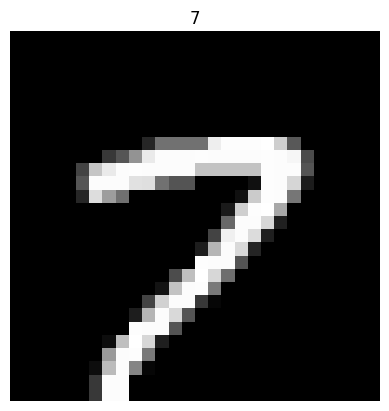

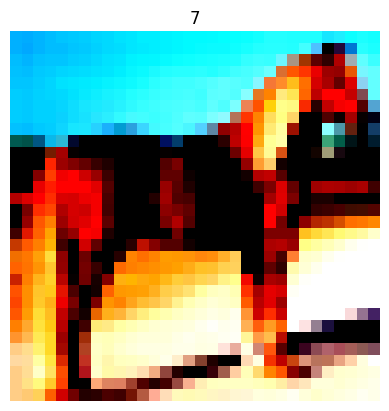

In [7]:
print(f"Mnist shape: {mnist_train_data[0][0].shape}\nsize: {len(mnist_train_data)}\nCifar10 shape: {cifar10_train_data[0][0].shape}\nsize: {len(cifar10_train_data)}")
#image check
img1, label1 = mnist_train_data[123]
img2, label2 = cifar10_train_data[43]

plt.imshow(img1.permute(1,2,0), cmap = "gray")
plt.title(label1)
plt.axis("off")
plt.show()

plt.imshow(img2.permute(1,2,0))
plt.title(label2)
plt.axis("off")
plt.show()



Model implementation

In [8]:
# =============================== MLP Implementation ===================================
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_size:int, hidden1:int, hidden2:int, output_size:int, dropout:float = 0):
        super().__init__()
        """
        Creates a Multilayerperceptron

        Args:
            input_size: size of the input, where the input is a vector
            hidden1: size of the first hidden layer
            hidden2: size of the second hidden layer
            output_size: the size of the output layer, mapping to the total number of classes

        """

        #input layer (flattening defauls 1 to -1)
        self.flatten = nn.Flatten()

        #first hidden layer
        self.hidden1 = nn.Linear(in_features = input_size,
                                 out_features = hidden1)

        #second hidden layer
        self.hidden2 = nn.Linear(in_features = hidden1,
                                 out_features = hidden2)

        #output layer
        self.output = nn.Linear(in_features = hidden2,
                                     out_features = output_size)

        #activation function
        self.relu = nn.ReLU()

        #dropout
        self.dropout = nn.Dropout(p=dropout)

    def forward(self,x: torch.Tensor):
            """
            Creates a forward pass for a single data-point through the first N-1 layers

            Args:
                x: an input vector of an image either of size (3,32,32) for RGB or (1,28,28) for Greyscale
            Returns:
                A vector of size (1,10) where each feature is weighted score (z_i) for neuron i
            """
            #here flatten the image through the input layer and pass it along
            #the hidden layers with their specified activation functions

            x = self.flatten(x)

            x = self.relu(self.hidden1(x))
            x = self.dropout(x)

            x = self.relu(self.hidden2(x))
            x = self.dropout(x)

            return self.output(x)

    def predict(self,x: torch.Tensor):
        """
        Determines the most likely class for a given data point

        Args:
            x: A Tensor of shape (3,32,32) for RGB or (1,28,28) for Greyscale representing an image

        Returns:
            x: An integer k, representing the class having the highest likelihood
        """
        #convert tensor elements to float
        x = x.float()
        outputs = self.forward(x)

        #not need for softmax, since logyhat grows with z
        return torch.argmax(outputs, dim = 1)




In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels:int, out_channels:int, kernel:int = 3, stride:int = 1, padding:int = 1):
        super().__init__()
        """
        Creates a standard convolutional block passing a data matrix through Conv2d->BatchNorm2d->ReLU

        Args:
            in_channels: the number of input channels
            out_channels: the number of feature maps required
            kernel: the size of the kernel either k for kxk or (w,h) as a tuple for w x h (default 3)
            stride: the number of pixels the filter must move at a time (default 1)
            padding: the padding applied
        """
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,out_channels, kernel,stride, padding),# (N,in_channels,H,W) -> (N,out_channels,H_out,W_out)
            nn.BatchNorm2d(out_channels), #(N,C,H,W) -> (N,C,H,W)
            nn.ReLU(inplace = True) #apply relu on the same tensor
        )


    def forward(self, x:torch.Tensor):
        """
        Performs one forward pass through the conv block

        Args:
            x: a tensor of shape (N,in_channels,H,W) holding a sequence of images

        Returns:
            A tensor of shape (N,out_channels, H_out, W_out) where H_out and W_out are a function of H,W,kernel,stride,padding
        """

        return self.block(x)

#================================= ConvNN ============================
class ConvNN(nn.Module):
    def __init__(self, in_channels:int,kernel = 3, dropout: float = 0.3):
        """
        Creates a Convolutional Neural Network Model

        Args:
            in_channels: the number of input matrixes representing an image
            dropout: the dropout rate

        """
        super().__init__()

        #Extract low-level features with stride downsampling
        self.stage1 = nn.Sequential(
            ConvBlock(in_channels,16, kernel = kernel),
            ConvBlock(16,16,kernel = kernel),
            ConvBlock(16,32,stride = 2, kernel = kernel) #downsampling without max pooling to maintain information
        )

        #Extract higher-level features and shapes
        self.stage2 = nn.Sequential(
            ConvBlock(32,32, kernel = kernel),
            ConvBlock(32,32, kernel = kernel),
            ConvBlock(32,64,stride = 2, kernel = kernel)#downsampling via stride
        )

        #Final extraction
        self.stage3 = nn.Sequential(
            ConvBlock(64,64, kernel = kernel), #at this stage could be (N,64,7,7) for mnist or (N,64,8,8)cifar
        )

        #Classifier
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), #global average pooling to generate (N,64,1,1)
            nn.Flatten(), #generates (N,64) input layer
            nn.Linear(64,256), #first FC layer
            nn.ReLU(inplace = True), #activation for first layer
            nn.Linear(256,128),
            nn.ReLU(inplace = True),
            nn.Dropout(p = dropout),
            nn.Linear(128,10)
        )

    def forward(self, x:torch.Tensor):
        """
        Performs one forward pass through the CNN

        Args:
            x: a tensor of shape (N,in_channels,H,W) holding a sequence of images
        Returns:
            A tensor of shape (N,10) of weighted sums
        """
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        return self.head(x)

    def predict(self, x:torch.Tensor):
        """
         Performs one forward pass through the CNN

        Args:
            x: a tensor of shape (N,in_channels,H,W) holding a sequence of images
        Returns:
            A tensor of shape (N,) representing the predicted image class for each image
        """
        x = self.forward(x)
        return torch.argmax(x, dim = 1)




In [10]:
#===================================================== Model Training ==============================================#
def accuracy(model: nn.Module, dataloader:torch.utils.data.DataLoader):
    """
    Computes the accuracy of a model based on a dataset in the dataloader

    Args:
        model: The model for which accuracy is being calculated
        dataloader: The dataloader for either training or development datasets

    Returns:
        Accuracy of model
    """
    #initialize totals
    total_datapoints = 0
    true_sum = 0

    with torch.no_grad():
        for images,labels in dataloader:
            images = images.to(device).float()
            labels = labels.to(device)
            #make prediction of documents
            predictions = model.predict(images.float())

            #compute mask
            mask =  (predictions == labels)

            #increment sums
            true_sum += mask.sum()
            total_datapoints+=labels.size(0)
    return true_sum/total_datapoints


def plot_functions(train_function: list[float],
                   val_function:list[float],
                   title:str,
                   ylabel:str = "Cross-entropy loss"
                   ):
    #show final loss functions
        plt.plot(train_function, label = "Training", color = "blue")
        plt.plot(val_function, label = "Validation", color = "orange")
        plt.ylabel(ylabel)
        plt.xlabel("Epoch")
        plt.title(title)
        plt.legend()
        plt.show()

def train_model( model: nn.Module,
               train_loader: DataLoader,
               val_loader: DataLoader,
               optimizer: torch.optim,
               epochs: int,
               patience: int = None,
               min_epochs: int = 0,
               verbose: bool = True,
               plot: bool = True,
               llambda: float = 0):

    """
    Trains a givem multilayer perceptron model using a pytorch training loop

    Args:
        model: The model which is being trained
        train_loader: The training dataset loader
        val_loader: The development/validation dataset loader
        optimizer: The optimizer used for gradient decent
        epochs: The number of full dataset passes during training
        alpha: The learning rate applied during training
        patience: The number of epochs allowed for validation loss to stop decreasing
        min_epochs: Specifies the minimum number of epochs allowed to continue training till early stopping is enabled
        verbose: Prints training progress at epoch if True
        plot: Shows loss function plot if true
        llambda: the llambda controlling the penalty during l1 regularization

    Return:
        A dictionary containing the training and validation loss function in the form {"train":train_loss, "val":val_loss}
    """
    assert epochs >= min_epochs


    #initialize best loss and weights
    best_loss = 10000
    best_weights = None
    patience_counter = 0

    #initialize lists for loss functions and accuracy curves
    train_loss_function = []
    val_loss_function =  []

    train_acc_function = []
    val_acc_function = []

    #send to GPU
    model.to(device)



    for epoch in range(1,epochs+1):

        #for average training loss
        weighted_train_loss = 0.0
        total_size_train = 0


        #set the model to training mode
        model.train()

        for i, (images,labels) in enumerate(train_loader):
            images = images.to(device).float()
            labels = labels.to(device).long()
            #print(f"batch: {i}")
            #Loss function
            logits = model(images)
            train_labels = labels
            loss = F.cross_entropy(logits,train_labels) #compute loss function

            #l1 regularizaton
            if llambda != 0:
                #calculate lp norm
                r = torch.norm(torch.cat([p.view(-1) for p in model.parameters()]), p=1)
                loss = loss + llambda * r

            #update weighted train loss
            weighted_train_loss += loss.item() * train_labels.size(0)
            total_size_train += train_labels.size(0)


            #Compute gradient and make update
            optimizer.zero_grad() #reset gradients
            loss.backward() #compute new gradients
            optimizer.step() #make updates


        weighted_val_loss = 0.0
        tot_size = 0

        #set the model to validation mode
        model.eval()

        #compute validation loss per epoch
        with torch.no_grad():#ensure no updates

            for val_images,val_labels in val_loader:
                #move images to gpu
                val_images = val_images.to(device).float()
                val_labels = val_labels.to(device).long()

                #compute loss
                val_logits = model(val_images)
                val_labels = val_labels
                batch_loss = F.cross_entropy(val_logits,val_labels)

                #get this batches contribution to loss
                weighted_val_loss += batch_loss.item() * val_labels.size(0) #gets the weighted contribution to loss of this batch
                tot_size += val_labels.size(0)

        #loss calculation
        avg_loss_val = weighted_val_loss/tot_size
        avg_loss_train = weighted_train_loss/total_size_train

        #keep track of training loss and validation loss
        train_loss_function.append(avg_loss_train)
        val_loss_function.append(avg_loss_val)

        val_acc = accuracy(model, val_loader)#always calculate val_acc
        if plot:
            #acc calculation
            train_acc =  accuracy(model, train_loader)


            #keep track of training and validation accuracy
            train_acc_function.append(train_acc.item())
            val_acc_function.append(val_acc.item())




        #early stopping based on loss change
        if patience is not None and epoch>=min_epochs:

            if avg_loss_val < best_loss:
                #update best loss
                best_loss = avg_loss_val
                best_weights = {key: params.clone() for key, params in model.state_dict().items()} #make a copy of the best weights and bias
                patience_counter = 0 #reset patience counter
            else:
                patience_counter +=1

            if patience_counter == patience:
                #replace current weights and bias
                model.load_state_dict(best_weights)

                #stop training
                break



        if verbose:
            print(f"Epoch {epoch:02d} | Train loss: {avg_loss_train:.4f} | Val loss: {avg_loss_val:.4f} | Val acc: {val_acc.item():.4f}")# | Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}")

    # if plot:
    #     #show final loss functions
    #     plot_functions(train_loss_function, val_loss_function)
    #     plot_functions(train_acc_function, val_acc_function)

    #return loss functions for analysis
    return {"train_loss":train_loss_function,
            "val_loss": val_loss_function,
            "train_acc": train_acc_function,
            "val_acc": val_acc_function
           }



## Model Training

 Since the purpose of this section is to compare the peformance of the 2 models, we do not need to optimize  hyperparameters. We will use the same training setup for each model type based on similar models used on MNIST and CIFAR10.

### Training choices:
 - Loss function: Cross entropy loss
 - Optimizer: SGD
 - Learning rate: 0.001
 - Number of epochs: early stopping with patience 4
 - Batch size: 64

### MLP Architecture
- 1 input layer, 2 Hidden layers and an output layer
- Hidden1 size : 128
- Hidden 2 size: 64
- Output size: 10

### CNN Architecture
- Conv Block:
- Kernel size : 3x3

In [ ]:
# ====================== Create dataloaders ====================================#
g = torch.Generator()
g.manual_seed(42)

#Mnist
mnist_train_loader = DataLoader(mnist_train_data, batch_size = 64, shuffle = True, generator = g)
mnist_test_loader = DataLoader(mnist_test_data, batch_size = 64)
mnist_val_loader = DataLoader(mnist_val_data, batch_size = 64)

#CIFAR
cifar10_train_loader = DataLoader(cifar10_train_data,batch_size = 64, shuffle = True, generator = g)
cifar10_test_loader = DataLoader(cifar10_test_data, batch_size=64)
cifar10_val_loader = DataLoader(cifar10_val_data, batch_size=64)




#========================= Build models =================================
#reseed
torch.manual_seed(42)

#cifar10 models & optimizers
cifar_mlp_model = MultiLayerPerceptron(input_size = 3*32*32,hidden1 = 128, hidden2=64, output_size = 10)
cifar_mlp_opt = torch.optim.SGD(cifar_mlp_model.parameters(), lr = 0.01)

cifar_cnn_model = ConvNN(in_channels = 3)
cifar_cnn_opt = torch.optim.Adam(cifar_cnn_model.parameters(), lr = 0.01)

#mnist models & optimizers
mnist_mlp_model = MultiLayerPerceptron(input_size = 28*28, hidden1 = 128, hidden2 = 64, output_size = 10)
mnist_mlp_opt = torch.optim.SGD(mnist_mlp_model.parameters(), lr = 0.01)

mnist_cnn_model = ConvNN(in_channels = 1)
mnist_cnn_opt = torch.optim.Adam(mnist_cnn_model.parameters(), lr = 0.01)


In [ ]:
#====================== Train Models =======================#
cifar_mlp_functions = train_model(model = cifar_mlp_model,
                                  train_loader = cifar10_train_loader,
                                  val_loader= cifar10_val_loader,
                                  optimizer=cifar_mlp_opt,
                                  epochs = 30,
                                  patience= 4,
                                  plot = True)

Epoch 01 | Train loss: 1.9056 | Val loss: 1.7068 | Val acc: 0.4004
Epoch 02 | Train loss: 1.6385 | Val loss: 1.5893 | Val acc: 0.4422
Epoch 03 | Train loss: 1.5385 | Val loss: 1.5284 | Val acc: 0.4656
Epoch 04 | Train loss: 1.4656 | Val loss: 1.4939 | Val acc: 0.4724
Epoch 05 | Train loss: 1.4079 | Val loss: 1.4471 | Val acc: 0.4890
Epoch 06 | Train loss: 1.3597 | Val loss: 1.4051 | Val acc: 0.5006
Epoch 07 | Train loss: 1.3193 | Val loss: 1.3993 | Val acc: 0.5020
Epoch 08 | Train loss: 1.2834 | Val loss: 1.4250 | Val acc: 0.4984
Epoch 09 | Train loss: 1.2492 | Val loss: 1.3786 | Val acc: 0.5228
Epoch 10 | Train loss: 1.2195 | Val loss: 1.3947 | Val acc: 0.5074
Epoch 11 | Train loss: 1.1909 | Val loss: 1.3631 | Val acc: 0.5178
Epoch 12 | Train loss: 1.1634 | Val loss: 1.3704 | Val acc: 0.5222
Epoch 13 | Train loss: 1.1401 | Val loss: 1.3875 | Val acc: 0.5098
Epoch 14 | Train loss: 1.1164 | Val loss: 1.4258 | Val acc: 0.5088


In [ ]:
cifar_cnn_functions = train_model(model = cifar_cnn_model,
                                  train_loader = cifar10_train_loader,
                                  val_loader= cifar10_val_loader,
                                  optimizer=cifar_cnn_opt,
                                  epochs = 30,
                                  patience= 4,
                                  plot = True)

Epoch 01 | Train loss: 1.7944 | Val loss: 1.5878 | Val acc: 0.3796
Epoch 02 | Train loss: 1.5223 | Val loss: 1.4555 | Val acc: 0.4664
Epoch 03 | Train loss: 1.3011 | Val loss: 1.2939 | Val acc: 0.5408
Epoch 04 | Train loss: 1.1232 | Val loss: 1.1220 | Val acc: 0.5994
Epoch 05 | Train loss: 1.0042 | Val loss: 0.9523 | Val acc: 0.6680
Epoch 06 | Train loss: 0.9062 | Val loss: 1.0921 | Val acc: 0.6546
Epoch 07 | Train loss: 0.8358 | Val loss: 0.7757 | Val acc: 0.7286
Epoch 08 | Train loss: 0.7768 | Val loss: 0.7530 | Val acc: 0.7352
Epoch 09 | Train loss: 0.7143 | Val loss: 0.7489 | Val acc: 0.7474
Epoch 10 | Train loss: 0.6691 | Val loss: 0.7618 | Val acc: 0.7558
Epoch 11 | Train loss: 0.6366 | Val loss: 0.7394 | Val acc: 0.7452
Epoch 12 | Train loss: 0.5993 | Val loss: 0.7096 | Val acc: 0.7636
Epoch 13 | Train loss: 0.5678 | Val loss: 0.6687 | Val acc: 0.7710
Epoch 14 | Train loss: 0.5437 | Val loss: 0.6569 | Val acc: 0.7822
Epoch 15 | Train loss: 0.5106 | Val loss: 0.6780 | Val acc: 0.

In [ ]:
mnist_mlp_functions = train_model(model = mnist_mlp_model,
                                  train_loader = mnist_train_loader,
                                  val_loader= mnist_val_loader,
                                  optimizer=mnist_mlp_opt,
                                  epochs = 30,
                                  patience= 4,
                                  plot = True)

Epoch 01 | Train loss: 0.8282 | Val loss: 0.3652 | Val acc: 0.8940
Epoch 02 | Train loss: 0.3169 | Val loss: 0.2823 | Val acc: 0.9168
Epoch 03 | Train loss: 0.2588 | Val loss: 0.2415 | Val acc: 0.9286
Epoch 04 | Train loss: 0.2220 | Val loss: 0.2130 | Val acc: 0.9348
Epoch 05 | Train loss: 0.1940 | Val loss: 0.1894 | Val acc: 0.9402
Epoch 06 | Train loss: 0.1719 | Val loss: 0.1701 | Val acc: 0.9480
Epoch 07 | Train loss: 0.1533 | Val loss: 0.1574 | Val acc: 0.9508
Epoch 08 | Train loss: 0.1384 | Val loss: 0.1447 | Val acc: 0.9538
Epoch 09 | Train loss: 0.1256 | Val loss: 0.1339 | Val acc: 0.9566
Epoch 10 | Train loss: 0.1148 | Val loss: 0.1240 | Val acc: 0.9580
Epoch 11 | Train loss: 0.1057 | Val loss: 0.1150 | Val acc: 0.9640
Epoch 12 | Train loss: 0.0974 | Val loss: 0.1118 | Val acc: 0.9638
Epoch 13 | Train loss: 0.0906 | Val loss: 0.1114 | Val acc: 0.9656
Epoch 14 | Train loss: 0.0842 | Val loss: 0.1009 | Val acc: 0.9680
Epoch 15 | Train loss: 0.0785 | Val loss: 0.1117 | Val acc: 0.

In [ ]:
mnist_cnn_functions = train_model(model = mnist_cnn_model,
                                  train_loader = mnist_train_loader,
                                  val_loader= mnist_val_loader,
                                  optimizer=mnist_cnn_opt,
                                  epochs = 30,
                                  patience= 4,
                                  plot = True)

Epoch 01 | Train loss: 0.3288 | Val loss: 0.2016 | Val acc: 0.9328
Epoch 02 | Train loss: 0.0928 | Val loss: 0.0552 | Val acc: 0.9860
Epoch 03 | Train loss: 0.0669 | Val loss: 0.1079 | Val acc: 0.9688
Epoch 04 | Train loss: 0.0594 | Val loss: 0.0516 | Val acc: 0.9826
Epoch 05 | Train loss: 0.0504 | Val loss: 0.0448 | Val acc: 0.9860
Epoch 06 | Train loss: 0.0474 | Val loss: 0.0490 | Val acc: 0.9846
Epoch 07 | Train loss: 0.0419 | Val loss: 0.0335 | Val acc: 0.9892
Epoch 08 | Train loss: 0.0383 | Val loss: 0.0636 | Val acc: 0.9816
Epoch 09 | Train loss: 0.0335 | Val loss: 0.0560 | Val acc: 0.9888
Epoch 10 | Train loss: 0.0359 | Val loss: 0.0321 | Val acc: 0.9906
Epoch 11 | Train loss: 0.0319 | Val loss: 0.0381 | Val acc: 0.9920
Epoch 12 | Train loss: 0.0298 | Val loss: 0.0461 | Val acc: 0.9896
Epoch 13 | Train loss: 0.0274 | Val loss: 0.0248 | Val acc: 0.9926
Epoch 14 | Train loss: 0.0303 | Val loss: 0.0367 | Val acc: 0.9884
Epoch 15 | Train loss: 0.0242 | Val loss: 0.0253 | Val acc: 0.

<a id="s2"></a>

## A4.2 - Results Table

In [ ]:
#determine accuracies
mnist_mlp_accuracy = accuracy(mnist_mlp_model, mnist_test_loader)*100
cifar10_mlp_accuracy = accuracy(cifar_mlp_model, cifar10_test_loader)*100

mnist_cnn_accuracy = accuracy(mnist_cnn_model, mnist_test_loader)*100
cifar10_cnn_accuracy = accuracy(cifar_cnn_model, cifar10_test_loader)*100

results = pd.DataFrame({"Dataset":["MNIST","CIFAR-10"],
                        "MLP Test Accuracy (%)":[mnist_mlp_accuracy.item(),cifar10_mlp_accuracy.item()],
                        "CNN Test Accuracy (%)":[mnist_cnn_accuracy.item(),cifar10_cnn_accuracy.item()]})
results.style.format({
    "MLP Test Accuracy (%)": "{:.2f}",
    "CNN Test Accuracy (%)": "{:.2f}"
})



,Dataset,MLP Test Accuracy (%),CNN Test Accuracy (%)
0,MNIST,98.06,99.50
1,CIFAR-10,51.90,79.54


<a id='s3'></a>
## A4.3 - Training and Validation Curves

 Below the performance of the MultiLayerPerceptron against that of the Convolutional Neural Network on both the MNIST (28*28) greyscale dataset and CIFAR10 (32*32) is compared. Graphical comparisons of loss and accuracy between both models on the same datasets are supplied. Using the graphical contrasts reasons for such results are discussed.

- MNIST Results
- CIFAR Results

Note that since early stopping was used, the number of epochs are not the same across the models. To contrast the curves for each implementation and epoch percentage based x-axis was used.

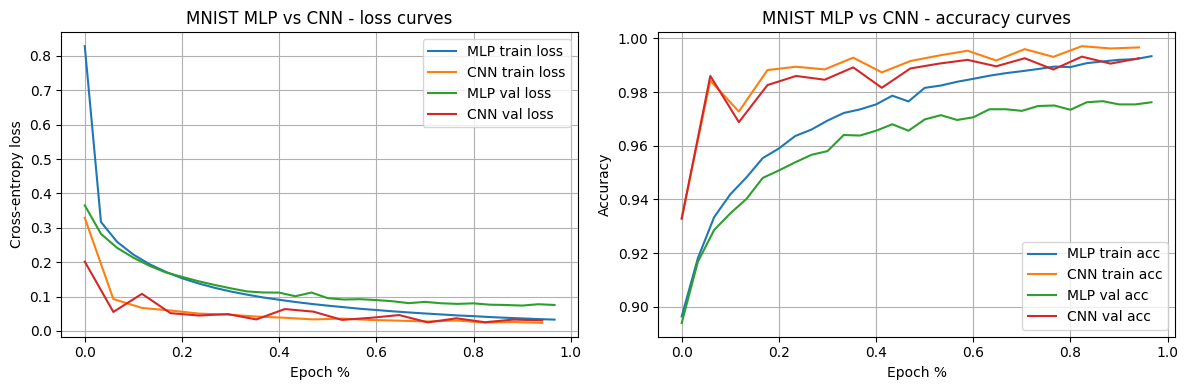

In [ ]:
#============================================= MNIST Curves ============================================#

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4))

#generate epoch percentage labels
mnist_mlp_epochs = len(mnist_mlp_functions["train_loss"])
mnist_cnn_epochs = len(mnist_cnn_functions["train_loss"])

mnist_mlp_train_loss_x = [i/mnist_mlp_epochs for i in range(mnist_mlp_epochs)]
mnist_cnn_train_loss_x = [i/mnist_cnn_epochs for i in range(mnist_cnn_epochs)]

#loss curves
ax1.plot(mnist_mlp_train_loss_x, mnist_mlp_functions["train_loss"], label = "MLP train loss" )
ax1.plot(mnist_cnn_train_loss_x, mnist_cnn_functions["train_loss"], label = "CNN train loss")
ax1.plot(mnist_mlp_train_loss_x, mnist_mlp_functions["val_loss"], label = "MLP val loss" )
ax1.plot(mnist_cnn_train_loss_x, mnist_cnn_functions["val_loss"], label = "CNN val loss")
ax1.set_xlabel("Epoch %")
ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("MNIST MLP vs CNN - loss curves")
ax1.legend()
ax1.grid(True)

#Accuracy curves
ax2.plot(mnist_mlp_train_loss_x, mnist_mlp_functions["train_acc"], label = "MLP train acc" )
ax2.plot(mnist_cnn_train_loss_x, mnist_cnn_functions["train_acc"], label = "CNN train acc")
ax2.plot(mnist_mlp_train_loss_x, mnist_mlp_functions["val_acc"], label = "MLP val acc")
ax2.plot(mnist_cnn_train_loss_x, mnist_cnn_functions["val_acc"], label = "CNN val acc")
ax2.set_xlabel("Epoch %")
ax2.set_ylabel("Accuracy")
ax2.set_title("MNIST MLP vs CNN - accuracy curves")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


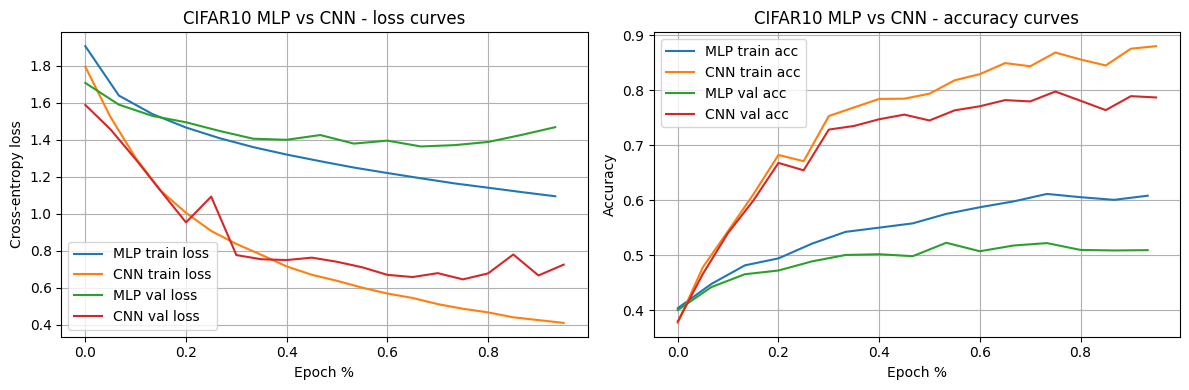

In [ ]:
#==================================== CIFAR-10 curves ================================

fig1, (ax3, ax4) = plt.subplots(1,2, figsize = (12,4))

#generate epoch percentage labels
cifar_mlp_epochs = len(cifar_mlp_functions["train_loss"])
cifar_cnn_epochs = len(cifar_cnn_functions["train_loss"])

cifar_mlp_train_loss_x = [i/cifar_mlp_epochs for i in range(cifar_mlp_epochs)]
cifar_cnn_train_loss_x = [i/cifar_cnn_epochs for i in range(cifar_cnn_epochs)]

#plot mlp and cnn cifar curves
ax3.plot(cifar_mlp_train_loss_x, cifar_mlp_functions["train_loss"], label = "MLP train loss" )
ax3.plot(cifar_cnn_train_loss_x, cifar_cnn_functions["train_loss"], label = "CNN train loss")
ax3.plot(cifar_mlp_train_loss_x, cifar_mlp_functions["val_loss"], label = "MLP val loss" )
ax3.plot(cifar_cnn_train_loss_x, cifar_cnn_functions["val_loss"], label = "CNN val loss")
ax3.set_xlabel("Epoch %")
ax3.set_ylabel("Cross-entropy loss")
ax3.set_title("CIFAR10 MLP vs CNN - loss curves")
ax3.legend()
ax3.grid(True)

ax4.plot(cifar_mlp_train_loss_x, cifar_mlp_functions["train_acc"], label = "MLP train acc" )
ax4.plot(cifar_cnn_train_loss_x, cifar_cnn_functions["train_acc"], label = "CNN train acc")
ax4.plot(cifar_mlp_train_loss_x, cifar_mlp_functions["val_acc"], label = "MLP val acc")
ax4.plot(cifar_cnn_train_loss_x, cifar_cnn_functions["val_acc"], label = "CNN val acc")
ax4.set_xlabel("Epoch %")
ax4.set_ylabel("Accuracy")
ax4.set_title("CIFAR10 MLP vs CNN - accuracy curves")
ax4.legend()
ax4.grid(True)


plt.tight_layout()
plt.show()

<a id='s4'></a>
## A4.4 - Analysis

On MNIST the performance gap between the MLP and CNN is small, only being visible in the early training phase (≈30-40% of epochs). Both models converge to a similar final performance, with the MLP reaching ~98% accuracy while the CNN reached ~99.1%, having both losses drop below ~0.1. This indicates that the task is low complexity, where spatial structure does not need to be maintained.

In contrast, on CIFAR-10, the gap opens early in training (≈10% of epochs) and remains constant thought both graphs. The MLP reaches ≈0.60 training accuracy and ≈0.51 validation accuracy, while the CNN maintains its performance, reaching a 0.88 training accuracy and ≈0.78-0.80 validation accuracy. This indicates a high task complexity, where spatial information must be maintained.

The reason in the difference of model performance with CIFAR-10 is model complexity and inductive bias. Since CIFAR-10 images contain more complex data (edges, shapes and objects), they depend on spatial structure. This is where CNN outperforms as it assumes that nearby pixels are related (inductive bias) whereas MLP treats each input as independent numbers. Furthermore, since CNN makes use of local receptive fields, even if objects move to different pixel postions, the model can still detect it.

<a id='s5'></a>
## A4.5 - Reflections

The MLP performs very well on MNIST scoring a test accuracy of 98.06%, but serverly drops on CIFAR-10 (50-52% validation accuracy). This drop is much more dramatic than that seen in CNN (≈10% decrease). This sharp drop in MLP performance is due to the strong spartial structure and local correlations in the CIFAR-10 images.

Since the MNIST images are simple, have a consistent structure and have low variablity (centered) MLP is able to fit the data. However, due to the complex nature of the CIFAR-10 images such as, complex shapes dependent on neigbhouring pixels and objects appearing in different positions, MLP fails. This is becuase MLP treats an image as a flatterned vector, ignoring any spatial relationshipts between pixels.

# Part B
Under part B we fix the number of parameters a given model can have to investigate the effects of architecture design on both the MLP model and CNN model on the CIFAR10 dataset. We aim to investigate the usage of parameters across the models.

- [B4.1: Architecture report](#s6)
- [B4.2: Base Model Training](#s7)
- [B4.3: Hyperparameter Tuning](#s8)
- [B4.4: Efficiency Analysis](#s9)
- [B4.5: Reflection](#s10)

In [11]:
#========================================= Parameter Budget Helpers =================================
def count_params(model:nn.Module):
    """
    Counts the total number of parameters in a model

    Args:
        model: The model which parameters must be counted

    Returns:
        A count of the number of parameters (learnable) in a model
    """
    return sum(p.numel() for p in model.parameters())

def layerwise_params(model):
    """
    Determines the number of parameters per layer widthin the model

    Args:
      model: The model which a layerwise parameter table will be produced
    """
    report = []
    total = 0

    for name, layer in model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            #account for weights and biases
            p = layer.in_features * layer.out_features + layer.out_features

        elif isinstance(layer, torch.nn.Conv2d):
            p = (layer.in_channels * layer.kernel_size[0] * layer.kernel_size[1] *
                 layer.out_channels) + layer.out_channels
        elif isinstance(layer, torch.nn.BatchNorm2d):
            p = layer.num_features * 2  # gamma + beta
        else:
            continue

        report.append((name, type(layer).__name__, p))
        total += p

    return report, total


<a id='s6'></a>
## B4.1 - Architecture Report

In [12]:
!pip install torchinfo

In [13]:
from torchinfo import summary

In [14]:
#================================= Redefined ConvNN ============================
class AdaptedConvNN(nn.Module):
    def __init__(self, in_channels:int,kernel = 3, dropout: float = 0.3):
        """
        Creates a Convolutional Neural Network Model

        Args:
            in_channels: the number of input matrixes representing an image
            dropout: the dropout rate

        """
        super().__init__()

        #Extract low-level features with stride downsampling
        self.stage1 = nn.Sequential(
            ConvBlock(in_channels,16, kernel = kernel),
            ConvBlock(16,16,kernel = kernel),
            ConvBlock(16,32,stride = 2, kernel = kernel) #downsampling without max pooling to maintain information
        )

        #Extract higher-level features and shapes
        self.stage2 = nn.Sequential(
            ConvBlock(32,32, kernel = kernel),
            ConvBlock(32,32, kernel = kernel),
            ConvBlock(32,64,stride = 2, kernel = kernel)#downsampling via stride
        )

        #Final extraction
        self.stage3 = nn.Sequential(
            ConvBlock(64,256, kernel = kernel), #at this stage could be (N,64,7,7) for mnist or (N,64,8,8)cifar
            ConvBlock(256,64),
            ConvBlock(64,128),
            #ConvBlock(64,64)
        )

        #Classifier
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), #global average pooling to generate (N,64,1,1)
            nn.Flatten(), #generates (N,64) input layer
            nn.Linear(128,256), #first FC layer
            nn.ReLU(inplace = True), #activation for first layer
            nn.Dropout(p = dropout),
            nn.Linear(256,128),
            nn.ReLU(inplace = True),
            nn.Dropout(p = dropout),
            nn.Linear(128,10)
        )

    def forward(self, x:torch.Tensor):
        """
        Performs one forward pass through the CNN

        Args:
            x: a tensor of shape (N,in_channels,H,W) holding a sequence of images
        Returns:
            A tensor of shape (N,10) of weighted sums
        """
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        return self.head(x)

    def predict(self, x:torch.Tensor):
        """
         Performs one forward pass through the CNN

        Args:
            x: a tensor of shape (N,in_channels,H,W) holding a sequence of images
        Returns:
            A tensor of shape (N,) representing the predicted image class for each image
        """
        x = self.forward(x)
        return torch.argmax(x, dim = 1)




In [15]:
#=================================== Fitting parameter budget ==========================
#define base models
mlp = MultiLayerPerceptron(input_size = 3*32*32, hidden1 = 144, hidden2 = 256, output_size = 10)
print(f"MLP Parameter count: {count_params(mlp)}")

cnn = AdaptedConvNN(in_channels = 3, kernel = 3)
print(f"CNN Parameter count: {count_params(cnn)}")

MLP Parameter count: 482202
CNN Parameter count: 481978


In [ ]:
#mlp model structure
print(f"{"MLP Budget Table":^30}\n")
mlp_report, mlp_total = layerwise_params(mlp)
mlp_table = pd.DataFrame(mlp_report, columns=["Layer", "Type", "Params"])
mlp_table.loc["TOTAL"] = ["-", "-", mlp_total]

display(mlp_table)
print()
#confirmation with summary
summary(mlp, input_size = (1,3,32,32))



       MLP Budget Table       



,Layer,Type,Params
0,hidden1,Linear,442512
1,hidden2,Linear,37120
2,output,Linear,2570
TOTAL,-,-,482202


Layer (type:depth-idx)                   Output Shape              Param #
MultiLayerPerceptron                     [1, 10]                   --
├─Flatten: 1-1                           [1, 3072]                 --
├─Linear: 1-2                            [1, 144]                  442,512
├─ReLU: 1-3                              [1, 144]                  --
├─Dropout: 1-4                           [1, 144]                  --
├─Linear: 1-5                            [1, 256]                  37,120
├─ReLU: 1-6                              [1, 256]                  --
├─Dropout: 1-7                           [1, 256]                  --
├─Linear: 1-8                            [1, 10]                   2,570
Total params: 482,202
Trainable params: 482,202
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.48
Input size (MB): 0.01
Forward/backward pass size (MB): 0.00
Params size (MB): 1.93
Estimated Total Size (MB): 1.94

In [ ]:
#cnn budget table
print(f"{"CNN Budget Table":^40}\n")
cnn_report, cnn_total = layerwise_params(cnn)
cnn_table = pd.DataFrame(cnn_report, columns=["Layer", "Type", "Params"])
cnn_table.loc["TOTAL"] = ["-", "-", cnn_total]

display(cnn_table)
print()
#confirmation using summary
summary(cnn, input_size = (1,3,32,32))

            CNN Budget Table            



,Layer,Type,Params
0,stage1.0.block.0,Conv2d,448
1,stage1.0.block.1,BatchNorm2d,32
2,stage1.1.block.0,Conv2d,2320
3,stage1.1.block.1,BatchNorm2d,32
4,stage1.2.block.0,Conv2d,4640
5,stage1.2.block.1,BatchNorm2d,64
6,stage2.0.block.0,Conv2d,9248
7,stage2.0.block.1,BatchNorm2d,64
8,stage2.1.block.0,Conv2d,9248
9,stage2.1.block.1,BatchNorm2d,64


Layer (type:depth-idx)                   Output Shape              Param #
AdaptedConvNN                            [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 16, 16]           --
│    └─ConvBlock: 2-1                    [1, 16, 32, 32]           --
│    │    └─Sequential: 3-1              [1, 16, 32, 32]           480
│    └─ConvBlock: 2-2                    [1, 16, 32, 32]           --
│    │    └─Sequential: 3-2              [1, 16, 32, 32]           2,352
│    └─ConvBlock: 2-3                    [1, 32, 16, 16]           --
│    │    └─Sequential: 3-3              [1, 32, 16, 16]           4,704
├─Sequential: 1-2                        [1, 64, 8, 8]             --
│    └─ConvBlock: 2-4                    [1, 32, 16, 16]           --
│    │    └─Sequential: 3-4              [1, 32, 16, 16]           9,312
│    └─ConvBlock: 2-5                    [1, 32, 16, 16]           --
│    │    └─Sequential: 3-5              [1, 32, 16, 16]           9,312
│ 

<a id='s7'></a>
## B4.2 - Base Model Training

Training the baseline models having parameters within the parameter budget (475000-525000). Base model hyperparameters:
- Batch size : 128
- Learning rate: 0.01
- Dropout: 0
- Patience: 5
- Min_epochs: 30

In [17]:
torch.manual_seed(42)
base_train_loader = DataLoader(cifar10_train_data, batch_size = 128, shuffle = True)
base_val_loader = DataLoader(cifar10_val_data, batch_size = 128)
base_test_loader = DataLoader(cifar10_test_data, batch_size = 128)

mlp_optimizer = torch.optim.SGD(mlp.parameters(), lr = 0.01)
cnn_optimizer = torch.optim.SGD(cnn.parameters(), lr = 0.01)

In [ ]:
start_time = time.time()

mlp_base_functions = train_model(mlp,base_train_loader,base_val_loader,mlp_optimizer,epochs=50, patience=5,min_epochs = 30, plot = False)

end_time = time.time()

training_time = end_time - start_time

Epoch 01 | Train loss: 2.0180 | Val loss: 1.8339 | Val acc: 0.3524
Epoch 02 | Train loss: 1.7596 | Val loss: 1.6951 | Val acc: 0.3988
Epoch 03 | Train loss: 1.6552 | Val loss: 1.6190 | Val acc: 0.4322
Epoch 04 | Train loss: 1.5869 | Val loss: 1.5656 | Val acc: 0.4542
Epoch 05 | Train loss: 1.5342 | Val loss: 1.5310 | Val acc: 0.4662
Epoch 06 | Train loss: 1.4902 | Val loss: 1.5118 | Val acc: 0.4740
Epoch 07 | Train loss: 1.4518 | Val loss: 1.4744 | Val acc: 0.4858
Epoch 08 | Train loss: 1.4170 | Val loss: 1.4518 | Val acc: 0.4902
Epoch 09 | Train loss: 1.3837 | Val loss: 1.4452 | Val acc: 0.4932
Epoch 10 | Train loss: 1.3539 | Val loss: 1.4197 | Val acc: 0.5032
Epoch 11 | Train loss: 1.3248 | Val loss: 1.4150 | Val acc: 0.4980
Epoch 12 | Train loss: 1.2981 | Val loss: 1.3993 | Val acc: 0.5060
Epoch 13 | Train loss: 1.2719 | Val loss: 1.3815 | Val acc: 0.5124
Epoch 14 | Train loss: 1.2479 | Val loss: 1.3733 | Val acc: 0.5150
Epoch 15 | Train loss: 1.2243 | Val loss: 1.3615 | Val acc: 0.

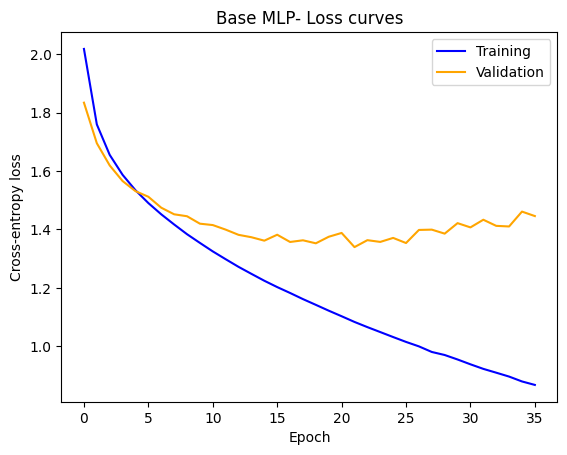


Base MLP training time: 611.5214s
Base MLP test accuracy: 0.5366


In [ ]:
#plot mlp base training data
plot_functions(mlp_base_functions["train_loss"],mlp_base_functions["val_loss"],"Base MLP- Loss curves")
#plot_functions(mlp_base_functions["train_acc"],mlp_base_functions["val_acc"], "Base MLP - Accuracy curves","Accuracy")
print(f"\nBase MLP training time: {training_time:.4f}s")
print(f"Base MLP test accuracy: {accuracy(mlp,base_test_loader).item():.4f}")

In [18]:
start1_time = time.time()

cnn_base_functions = train_model(cnn,base_train_loader,base_val_loader,cnn_optimizer,epochs=50, patience=5,min_epochs = 30,plot = False)

end1_time = time.time()

training1_time = end1_time - start1_time


Epoch 01 | Train loss: 2.2736 | Val loss: 2.1880 | Val acc: 0.2050
Epoch 02 | Train loss: 2.0528 | Val loss: 1.9211 | Val acc: 0.2650
Epoch 03 | Train loss: 1.8100 | Val loss: 1.6960 | Val acc: 0.3384
Epoch 04 | Train loss: 1.6489 | Val loss: 1.5503 | Val acc: 0.3990
Epoch 05 | Train loss: 1.5238 | Val loss: 1.4477 | Val acc: 0.4518
Epoch 06 | Train loss: 1.4010 | Val loss: 1.3984 | Val acc: 0.4680
Epoch 07 | Train loss: 1.2921 | Val loss: 1.2563 | Val acc: 0.5276
Epoch 08 | Train loss: 1.2037 | Val loss: 1.2339 | Val acc: 0.5500
Epoch 09 | Train loss: 1.1270 | Val loss: 1.1587 | Val acc: 0.5720
Epoch 10 | Train loss: 1.0537 | Val loss: 1.3476 | Val acc: 0.5198
Epoch 11 | Train loss: 0.9899 | Val loss: 1.0288 | Val acc: 0.6182
Epoch 12 | Train loss: 0.9313 | Val loss: 0.9578 | Val acc: 0.6646
Epoch 13 | Train loss: 0.8826 | Val loss: 1.0035 | Val acc: 0.6486
Epoch 14 | Train loss: 0.8361 | Val loss: 1.0160 | Val acc: 0.6484
Epoch 15 | Train loss: 0.7895 | Val loss: 0.9732 | Val acc: 0.

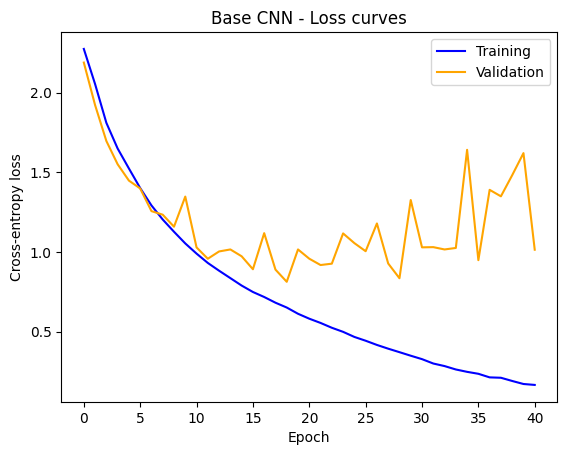


Base CNN training time: 748.4101s
Base CNN test accuracy: 0.7520


In [21]:
plot_functions(cnn_base_functions["train_loss"],cnn_base_functions["val_loss"],"Base CNN - Loss curves")

print(f"\nBase CNN training time: {training1_time:.4f}s")
print(f"Base CNN test accuracy: {accuracy(cnn,base_test_loader).item():.4f}")



<a id='s8'></a>
## B4.3 - Hyperparameter search
Using the base models as reference, a grid search is implemented to find the most optimal hyperparameters (learning rate, batch_size and dropout). Based on industry results, only a few set of combinations were choosen to avoid computational redundency, these values are:
- learing rates : {0.01, 0.001}
- batch sizes: {64, 128}
- dropouts: {0, 0.5}


In [ ]:
def run_optimization(model_type: nn.Module,
                     train_data:torch.utils.data.Dataset,
                     val_data:torch.utils.data.Dataset,
                     weight_decay: float = 0):
    """
    Performs hyperparameter tuning to find the best hyperparameters for a given model

    Args:
        train_dataset: The training dataset used to fit model
        dev_dataset: The development/validaton dataset used to compute accuracies and losses
        weight_decay: The contribution made

    """
    #hyper parameters to be tested
    learning_rates = [0.01, 0.001]
    batch_sizes =  [64,128]
    dropouts = [0,0.5]

    #create log to store accuracies
    log = []
    torch.manual_seed(42)#seed for reproducability


    for lr in learning_rates:
            for batch in batch_sizes:
                #implement batch size
                train_loader = DataLoader(train_data, batch_size = batch, shuffle = True)
                val_loader = DataLoader(val_data, batch_size = batch)


                for dropout in dropouts:
                    model = None

                    if model_type == ConvNN:
                        model = ConvNN(in_channels = 3,dropout = dropout, kernel = 3)
                    else:
                        model = MultiLayerPerceptron( input_size = 3*32*32,
                                                     hidden1 = 144,#use architecture withing budget
                                                     hidden2 = 256,
                                                     output_size = 10,
                                                     dropout = dropout)

                    optimizer = torch.optim.SGD(model.parameters(), lr = lr, weight_decay= weight_decay)

                    train_model(model,train_loader,val_loader,optimizer,epochs=30, patience=4,plot = False,verbose = False)

                    val_accuracy = accuracy(model, val_loader)
                    print(f"Alpha:{lr:^10}Batch:{batch:^10}Dropout:{dropout:^10}Accuracy:{val_accuracy:^10.4f}")
                    log.append([lr,batch,dropout,val_accuracy])#update log

    df_results = pd.DataFrame(log,columns =["Alpha","Batch","Dropout","Val Accuracy"])
    return df_results


In [ ]:
#CNN model tuning
#mnist
mlp_tuning_table = run_optimization(model_type = MultiLayerPerceptron,
                                    train_data = cifar10_train_data,
                                    val_data = cifar10_val_data)


Alpha:   0.01   Batch:    64    Dropout:    0     Accuracy:  0.5306  
Alpha:   0.01   Batch:    64    Dropout:   0.5    Accuracy:  0.5156  
Alpha:   0.01   Batch:   128    Dropout:    0     Accuracy:  0.5292  
Alpha:   0.01   Batch:   128    Dropout:   0.5    Accuracy:  0.5000  
Alpha:  0.001   Batch:    64    Dropout:    0     Accuracy:  0.4724  
Alpha:  0.001   Batch:    64    Dropout:   0.5    Accuracy:  0.4376  
Alpha:  0.001   Batch:   128    Dropout:    0     Accuracy:  0.4422  
Alpha:  0.001   Batch:   128    Dropout:   0.5    Accuracy:  0.4030  


In [ ]:
#cifar10
cnn_tuning_table = run_optimization(model_type = ConvNN,
                                      train_data = cifar10_train_data,
                                      val_data = cifar10_val_data)

Alpha:   0.01   Batch:    64    Dropout:    0     Accuracy:  0.6672  
Alpha:   0.01   Batch:    64    Dropout:   0.5    Accuracy:  0.6104  
Alpha:   0.01   Batch:   128    Dropout:    0     Accuracy:  0.6764  
Alpha:   0.01   Batch:   128    Dropout:   0.5    Accuracy:  0.6618  
Alpha:  0.001   Batch:    64    Dropout:    0     Accuracy:  0.4532  
Alpha:  0.001   Batch:    64    Dropout:   0.5    Accuracy:  0.4174  
Alpha:  0.001   Batch:   128    Dropout:    0     Accuracy:  0.3166  


MLP best combination
- Learning rate: 0.01
- Batch size: 64
- Dropout: 0

CNN best combination
- Learning rate: 0.01
- Batch size: 128
- Dropout: 0

<a id='s9'></a>
## B4.4 - Efficiency Analysis

At a fixed parameter budget (475,000-525,000) the CNN outperforms the MLP because its parameters are concentrated in feature extraction, wheras the MLP spreads its parameters across unstructured connections between all pixels.
This is evident through the parameter tables provided in B4.1. For the CNN about 86% of parameters are  allocated to feature extraction, wheras the MLP assigns nearly all its weights to fully connected layers, leading to learning redundant relationships.

Furthermore, the structure of the CNN allows for it to maintain the spartial information of the data, by applying convolutional filters over local regions (maintaining the structure of that region) which are shared across the whole image. Since these parameters are reused, they become more useful in capturing edges, textures and shapes. This discribed is inductive bias, which leads to improved generalization as translation invariance is maintained i.e. recognizing an object regardless of its position in a new image.

Although the MLP maintained a lower training time (611.52), due to its lack of inductive bias, it produced a low test accuracy of 0.536 as compared to CNNs 0.752 test accuracy. The prolonged training time (748.41s) on the CNN is expected due to the computational cost of convolutions, however this trade-off results in better generalizations.

<a id='s10'></a>
## B4.5 - Reflection

Instead of having full dense connections in the first layer, the MLP can be modified by introducing local connectivity. This means having each unit connect only to a small spatial patch of the image (sparse connections), where multiple units cover different regions of the image. Although inputs would be linear, this modification will better attempt to maintain local correlations by learning localized features. This approach still differs with convolution since weights are not shared accross local regions (each unit maintains its own set of weights)

#